<font color="black"><font size="7"><br>
     Projet 5 - Clustering 
</font>
    

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler
import category_encoders as ce
import plotly.graph_objects as go
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import plotly.express as px
import plotly.graph_objects as go
from sklearn.impute import SimpleImputer

%matplotlib inline

# Importing data

In [58]:
full_df = pd.read_pickle('data/full_df')
quarters_df = np.load('data/quarters_df.npy', allow_pickle=True)

## RFM scores calculation

In [59]:
def create_rfm_scores(df_final):
    quantile = df_final.quantile(q=[0.2, 0.4, 0.6, 0.8])
    # Frequency score
    df_final['frequency_score'] = [2 if 0 < f <= 1
                                   else 1 for f in df_final['frequency']]
    # Recency score
    df_final['recency_score'] = [1 if 0 < f <= quantile.iloc[0]['recency']
                                 else 2 if quantile.iloc[0]['recency'] < f <= quantile.iloc[1]['recency']
                                 else 3 if quantile.iloc[1]['recency'] < f <= quantile.iloc[2]['recency']
                                 else 4 if quantile.iloc[2]['recency'] < f <= quantile.iloc[3]['recency']
                                 else 5 for f in df_final['recency']]
    # Monetary score
    df_final['monetary_score'] = [5 if 0 < f <= quantile.iloc[0]['monetary_log']
                                  else 4 if quantile.iloc[0]['monetary_log'] < f <= quantile.iloc[1]['monetary_log']
                                  else 3 if quantile.iloc[1]['monetary_log'] < f <= quantile.iloc[2]['monetary_log']
                                  else 2 if quantile.iloc[2]['monetary_log'] < f <= quantile.iloc[3]['monetary_log']
                                  else 1 for f in df_final['monetary_log']]

    # Final score
    df_final['RFM_score'] = df_final['frequency_score'] + \
        df_final['recency_score'] + df_final['monetary_score']

    return df_final

In [60]:
full_df = create_rfm_scores(full_df)

In [61]:
for i in range(len(quarters_df)):
    quarters_df[i] = create_rfm_scores(quarters_df[i])

### EDA

#### ANOVA

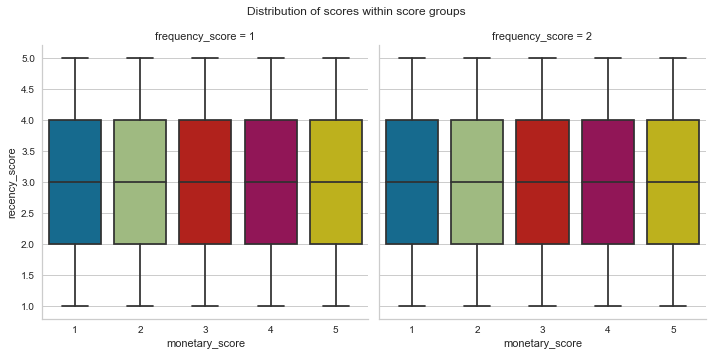

In [62]:
sns.catplot(x='monetary_score',
            y='recency_score',
            col='frequency_score',
            kind='box',
            data=full_df)
plt.suptitle('Distribution of scores within score groups')
plt.tight_layout()
plt.show()

### Manual Clustering

In [63]:
full_df['RFM_manual_cluster'] = [1 if 3 <= f <= 5
                                 else 2 if 6 <= f <= 9
                                 else 3 for f in full_df['RFM_score']]

In [64]:
full_df['RFM_manual_cluster'].unique()

array([2, 1, 3], dtype=int64)

#### Cluster analysis

In [65]:
silh_scores = {}

In [66]:
silh_scores['Manual RFM'] = silhouette_score(full_df[['frequency_score',
                                                      'recency_score',
                                                      'monetary_score']], full_df['RFM_manual_cluster'])

In [67]:
silhouettes_rfm = silhouette_samples(full_df[['frequency_score',
                                              'recency_score',
                                              'monetary_score']],
                                     full_df['RFM_manual_cluster'])

In [68]:
full_df['silhouette_rfm_coef'] = silhouettes_rfm

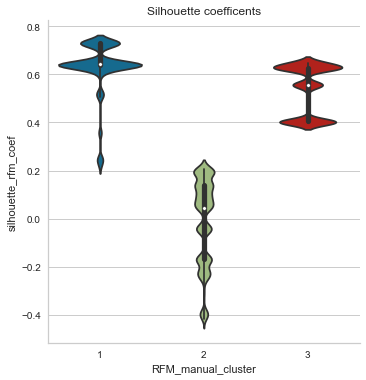

In [69]:
sns.catplot(x='RFM_manual_cluster', y='silhouette_rfm_coef',
            data=full_df, kind='violin')
plt.title('Silhouette coefficents')
plt.show()

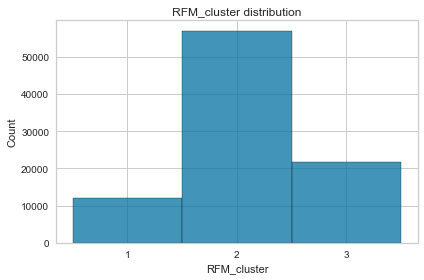

In [70]:
fig, ax = plt.subplots()

sns.histplot(full_df['RFM_manual_cluster'], discrete=True, ax=ax)


plt.title('RFM_cluster distribution')
plt.xlabel('RFM_cluster')
plt.xticks([1, 2, 3], ['1', '2', '3'])


plt.tight_layout()
plt.show()

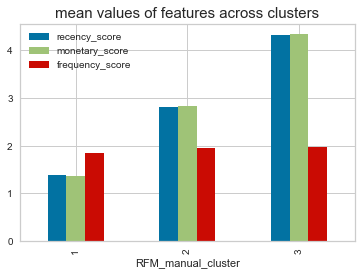

In [71]:
full_df.groupby('RFM_manual_cluster').mean()[
    ['recency_score', 'monetary_score', 'frequency_score']].plot(kind='bar')
plt.title('mean values of features across clusters', fontsize=15)
plt.show()

#### Cluster profile

In [72]:
A = full_df.groupby('RFM_manual_cluster').mean()[
    ['recency_score', 'monetary_score', 'frequency_score']]

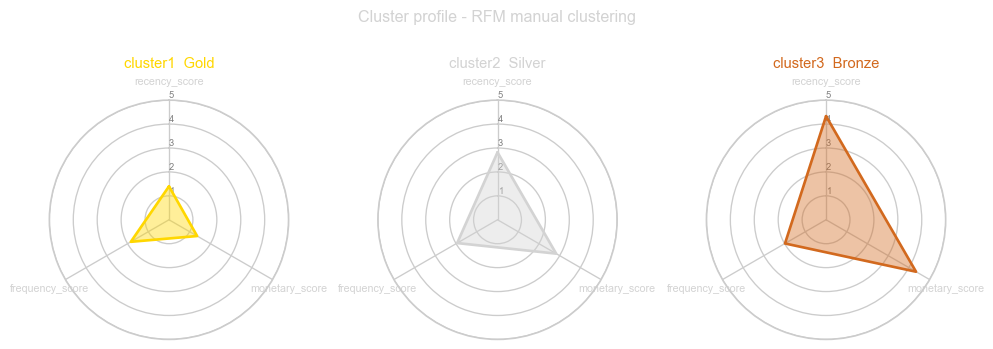

In [73]:
from math import pi
# ------- PART 1: Define a function that do a plot for one line of the dataset!


def make_spider(data, row, title, color):

    # number of variable
    categories = list(data)
    N = len(categories)

    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialise the spider plot
    ax = plt.subplot(3, 3, row, polar=True, )

    # If you want the first axis to be on top:
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories, color='lightgrey', size=8)

    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3",
                                 "4", "5"], color="grey", size=7)
    plt.ylim(0, 5)

    # Ind1
    values = data.loc[row].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)

    # Add a title
    plt.title(title, size=11, color=color, y=1.1)
    return None


# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi = 96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)

# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['gold', 'lightgrey', 'chocolate']
labels = ['Gold', 'Silver', 'Bronze']

# Loop to plot
for row in range(0, len(A.index)):
    make_spider(data=A, row=row+1, title='cluster'+str(row+1) +
                '  ' + str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile - RFM manual clustering', color='lightgrey')
plt.tight_layout()

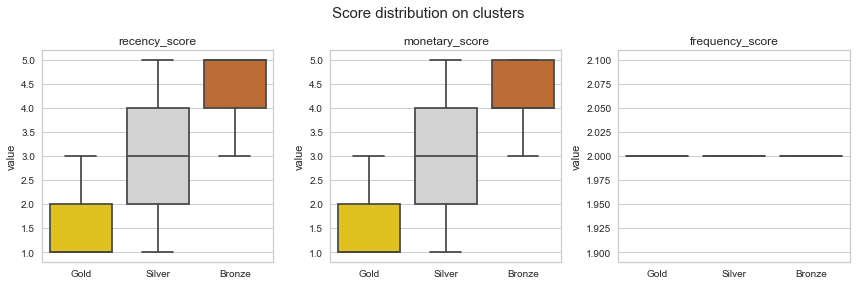

In [74]:
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(12, 4)
i = 0
for col in ['recency_score', 'monetary_score', 'frequency_score']:
    ax = axes[i % 3]
    sns.boxplot(x='RFM_manual_cluster',
                y=col,
                data=full_df,
                # palette='rainbow',
                palette=my_palette,
                showfliers=False,
                ax=ax
                )
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.set_xticklabels(['Gold', 'Silver', 'Bronze'])
    ax.set_ylabel('value')
    i += 1
fig.suptitle('Score distribution on clusters', fontsize=15)
plt.tight_layout()
plt.show()

## K-means

### Standard Scaler

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    full_df[['recency_score', 'monetary_score', 'frequency_score']])
model = KMeans(n_clusters=3)
model.fit(X_scaled)

KMeans(n_clusters=3)

In [76]:
full_df['class_predicted_k_3_SS'] = model.predict(X_scaled)+1
silh_scores['kmeans k=3 SS'] = silhouette_score(full_df[['frequency_score', 'recency_score', 'monetary_score']],
                                                full_df['class_predicted_k_3_SS'])

### Quantile Transformer

In [77]:
scaler = QuantileTransformer()

In [78]:
X_scaled = scaler.fit_transform(
    full_df[['recency_score', 'monetary_score', 'frequency_score']])

In [79]:
model = KMeans(n_clusters=3)

In [80]:
model.fit(X_scaled)

KMeans(n_clusters=3)

In [81]:
full_df['class_predicted_k_3_QT'] = model.predict(X_scaled)+1

In [82]:
silh_scores['kmeans k=3 QT'] = silhouette_score(full_df[['frequency_score', 'recency_score', 'monetary_score']],
                                                full_df['class_predicted_k_3_QT'])

In [83]:
silh_scores

{'Manual RFM': 0.20795312429036944,
 'kmeans k=3 SS': 0.26825863449089205,
 'kmeans k=3 QT': 0.38812702706029406}

### Comparing clustering

#### Calculating silhouette per samples

In [84]:
full_df['silhouette_RFM'] = silhouette_samples(full_df[['frequency_score', 'recency_score', 'monetary_score']],
                                               full_df['RFM_manual_cluster'])

In [85]:
full_df['silhouette_k_3_SS'] = silhouette_samples(full_df[['frequency_score', 'recency_score', 'monetary_score']],
                                                  full_df['class_predicted_k_3_SS'])

In [86]:
full_df['silhouette_k_3_QT'] = silhouette_samples(full_df[['frequency_score', 'recency_score', 'monetary_score']],
                                                  full_df['class_predicted_k_3_QT'])

#### Cluster visualisation

Text(0.5, 1.0, 'Silhouette coefficents with k-means - k=3 - QuantileTransformer')

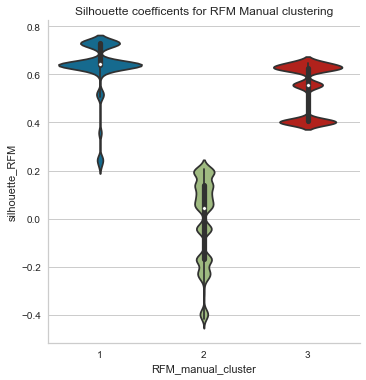

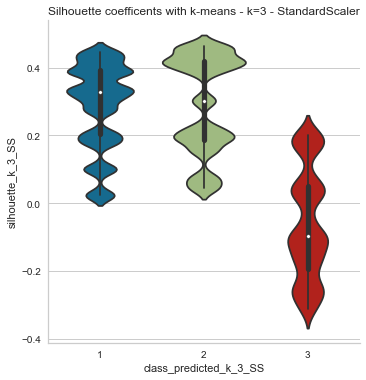

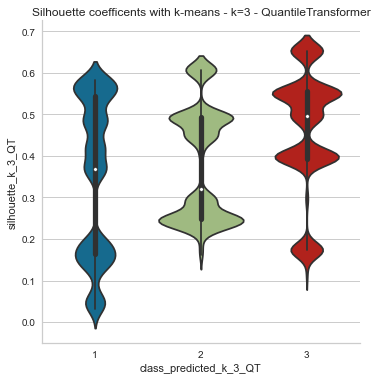

In [87]:
g1 = sns.catplot(x='RFM_manual_cluster', y='silhouette_RFM',
                 data=full_df, kind='violin',)
plt.title('Silhouette coefficents for RFM Manual clustering')

g2 = sns.catplot(x='class_predicted_k_3_SS',
                 y='silhouette_k_3_SS', data=full_df, kind='violin')
plt.title('Silhouette coefficents with k-means - k=3 - StandardScaler')

g3 = sns.catplot(x='class_predicted_k_3_QT',
                 y='silhouette_k_3_QT', data=full_df, kind='violin')
plt.title('Silhouette coefficents with k-means - k=3 - QuantileTransformer')

In [88]:
B = full_df.groupby('class_predicted_k_3_SS').mean()[
    ['recency_score', 'monetary_score', 'frequency_score']]

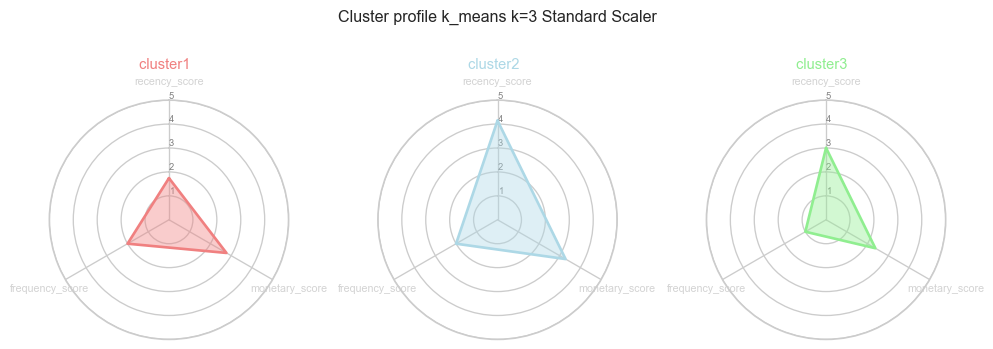

In [89]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi = 96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)

# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral', 'lightblue', 'lightgreen']
labels = ['', '', '']

# Loop to plot
for row in range(0, len(B.index)):
    make_spider(data=B, row=row+1, title='cluster'+str(row+1) +
                '  ' + str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=3 Standard Scaler')
plt.tight_layout()

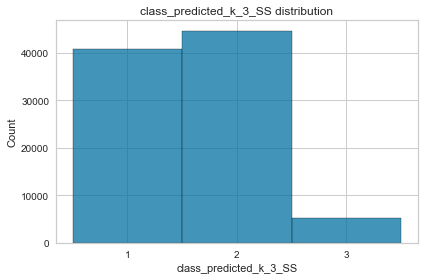

In [90]:
fig, ax = plt.subplots()

sns.histplot(full_df['class_predicted_k_3_SS'], discrete=True, ax=ax)


plt.title('class_predicted_k_3_SS distribution')
plt.xlabel('class_predicted_k_3_SS')
plt.xticks([1, 2, 3], ['1', '2', '3'])


plt.tight_layout()
plt.show()

In [91]:
C = full_df.groupby('class_predicted_k_3_QT').mean()[
    ['recency_score', 'monetary_score', 'frequency_score']]

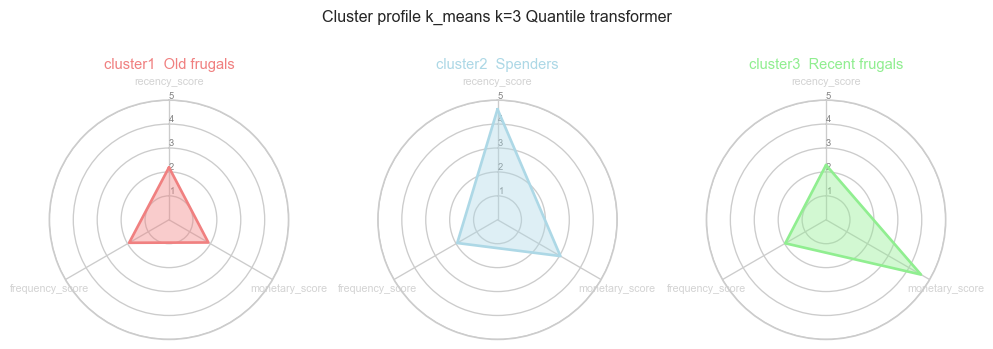

In [92]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi = 96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)

# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral', 'lightblue', 'lightgreen']
labels = ['Old frugals', 'Spenders', 'Recent frugals']

# Loop to plot
for row in range(0, len(C.index)):
    make_spider(data=C, row=row+1, title='cluster'+str(row+1) +
                '  ' + str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=3 Quantile transformer')
plt.tight_layout()

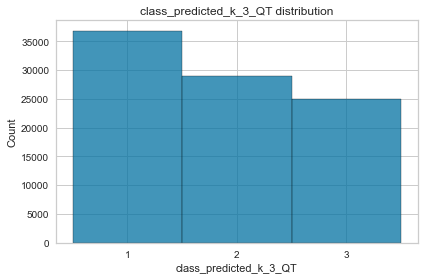

In [93]:
fig, ax = plt.subplots()

sns.histplot(full_df['class_predicted_k_3_QT'], discrete=True, ax=ax)


plt.title('class_predicted_k_3_QT distribution')
plt.xlabel('class_predicted_k_3_QT')
plt.xticks([1, 2, 3], ['1', '2', '3'])


plt.tight_layout()
plt.show()

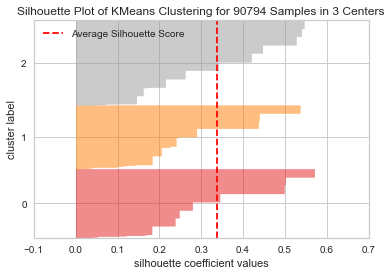

<AxesSubplot:title={'center':'Silhouette Plot of KMeans Clustering for 90794 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [44]:
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the dataa to the visualizer
visualizer.poof()    # Draw/show/poof the data

### Optimising number of clusters

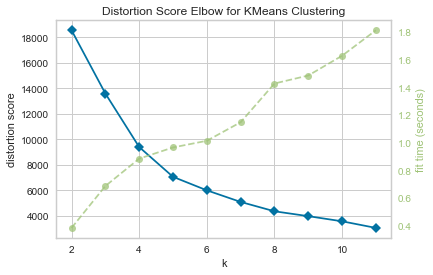

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [94]:
k_model = KMeans()
# Instantiate the clustering model and visualizer

visualizer = KElbowVisualizer(k_model, k=(2, 12), locate_elbow=False)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [95]:
model = KMeans(n_clusters=5)

In [96]:
model.fit(X_scaled)

KMeans(n_clusters=5)

In [97]:
full_df['class_predicted_k_5'] = model.predict(X_scaled)+1

In [98]:
full_df['silhouette_k_5'] = silhouette_samples(
    full_df[['frequency_score', 'recency_score', 'monetary_score']], full_df['class_predicted_k_5'])

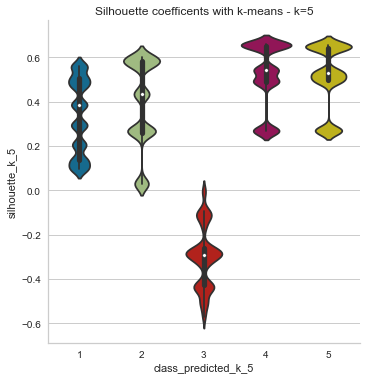

In [99]:
sns.catplot(x='class_predicted_k_5', y='silhouette_k_5',
            data=full_df, kind='violin')
plt.title('Silhouette coefficents with k-means - k=5')
plt.show()

In [100]:
silh_scores['kmeans k=5'] = silhouette_score(
    full_df[['frequency_score', 'recency_score', 'monetary_score']], full_df['class_predicted_k_5'])

In [101]:
silh_scores

{'Manual RFM': 0.20795312429036944,
 'kmeans k=3 SS': 0.26825863449089205,
 'kmeans k=3 QT': 0.38812702706029406,
 'kmeans k=5': 0.3808938773095665}

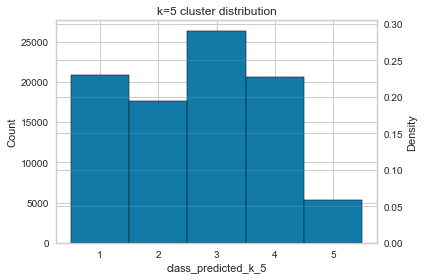

In [53]:
fig, ax = plt.subplots()

sns.histplot(full_df['class_predicted_k_5'], discrete=True, ax=ax)

ax2 = ax.twinx()
sns.histplot(full_df['class_predicted_k_5'],
             stat='density', discrete=True, ax=ax2)

plt.title('k=5 cluster distribution')
plt.xlabel('Cluster')
plt.xticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'])


plt.tight_layout()
plt.show()

In [54]:
C = full_df.groupby('class_predicted_k_5').mean()[
    ['recency_score', 'monetary_score', 'frequency_score']]

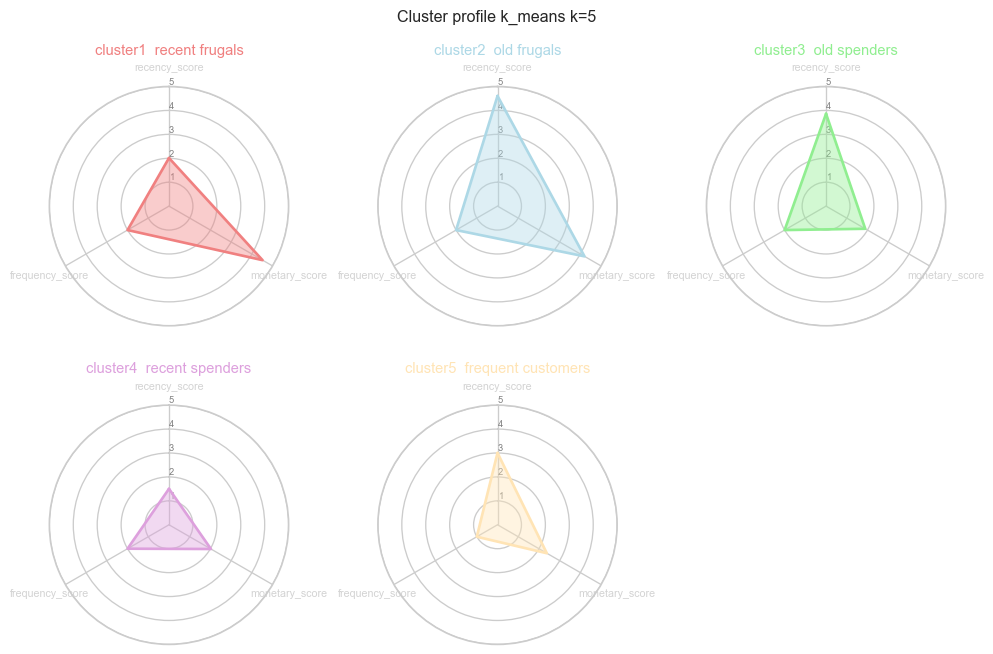

In [169]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi = 96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)

# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral', 'lightblue', 'lightgreen', 'plum', 'moccasin']
labels = ['recent frugals', 'old frugals', 'old spenders',
          'recent spenders', 'frequent customers']

# Loop to plot
for row in range(0, len(C.index)):
    make_spider(data=C, row=row+1, title='cluster'+str(row+1) +
                '  ' + str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=5')
plt.tight_layout()

### Using variables selected from pca

creating a new feature

In [106]:
full_df['payment_install_log'] = np.log(full_df['payment_installments']+1)

In [107]:
feature_pca_QT = ['review_score_QT',
                  'monetary_QT',
                  'payment_installments_QT',
                  'recency_QT',
                  'review_counts_QT',
                  'frequency_QT']

In [108]:
def compute_kmeans(data, cols, k, min_feat=2, max_feat=7):
    db = []
    for i in range(min_feat, max_feat+1):
        imputer = SimpleImputer()
        X = data[cols[0:i]]
        X_scaled = imputer.fit_transform(X)
        model = KMeans(n_clusters=k)
        model.fit(X_scaled)
        db.append(davies_bouldin_score(X_scaled, model.predict(X_scaled)))
    return db

#### Best number of variables

In [109]:
db_per_k = pd.DataFrame(index=np.arange(2, 7+1))

In [112]:
for k in range(2, 7):
    name = 'k=' + str(k)
    db_per_k[name] = compute_kmeans(
        full_df, feature_pca_QT, k, min_feat=2, max_feat=7)

In [113]:
db_per_k.index.name = 'nb_features'

In [114]:
db_per_k

,k=2,k=3,k=4,k=5,k=6
nb_features,,,,,
2,0.679326,0.504381,0.626033,0.601993,0.725737
3,0.968973,0.873096,0.983346,0.843532,0.800708
4,1.203367,1.270381,1.409822,1.275447,1.253006
5,1.293888,1.389857,1.208617,1.317083,1.219068
6,1.353425,1.052996,1.142161,1.268456,1.179088
7,1.353425,1.052996,1.140624,1.268404,1.179527


In [115]:
X_scaled = scaler.fit_transform(full_df[['review_score_QT',
                                         'monetary_QT',
                                         'payment_installments_QT',
                                         ]])

In [117]:
imputer = SimpleImputer()

In [118]:
X_scaled = imputer.fit_transform(X_scaled)

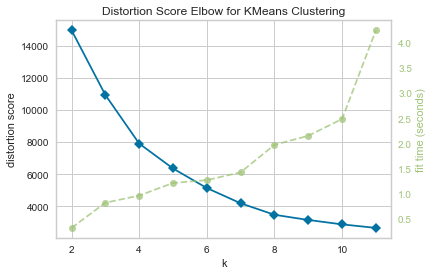

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [119]:
k_model = KMeans()
# Instantiate the clustering model and visualizer

visualizer = KElbowVisualizer(k_model, k=(2, 12), locate_elbow=False)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [120]:
model = KMeans(n_clusters=5)

In [121]:
model.fit(X_scaled)

KMeans(n_clusters=5)

In [122]:
full_df['class_predicted_k_5_pca'] = model.predict(X_scaled)+1

In [123]:
silh_scores['kmeans k=5 pca'] = silhouette_score(X_scaled,
                                                 full_df['class_predicted_k_5_pca'])

In [125]:
silh_scores

{'Manual RFM': 0.20795312429036944,
 'kmeans k=3 SS': 0.26825863449089205,
 'kmeans k=3 QT': 0.38812702706029406,
 'kmeans k=5': 0.3808938773095665,
 'kmeans k=5 pca': 0.4226852332536575}

In [124]:
# Visualisation

In [126]:
def create_visualisation_score(data, cols, transformer):
    for col in cols:
        new_col_values = transformer.fit_transform(
            np.array(data[col]).reshape(-1, 1))
        new_col_name = str(col)+'_trans'
        data[new_col_name] = new_col_values
    return data

In [128]:
full_df = create_visualisation_score(full_df, ['review_score',
                                               'monetary_log',
                                               'payment_install_log',
                                               'review_counts'], MinMaxScaler(feature_range=(0, 5)))

In [129]:
D = full_df.groupby('class_predicted_k_5_pca').mean()[['review_score_trans',
                                                       'monetary_log_trans',
                                                       'payment_install_log_trans']]

In [131]:
D

,review_score_trans,monetary_log_trans,payment_install_log_trans
class_predicted_k_5_pca,,,
1,5.000000,2.697793,1.081424
2,2.199415,2.809671,2.405516
3,5.000000,2.733587,2.678893
4,5.000000,2.068085,1.338214
5,2.408762,2.195910,1.305424


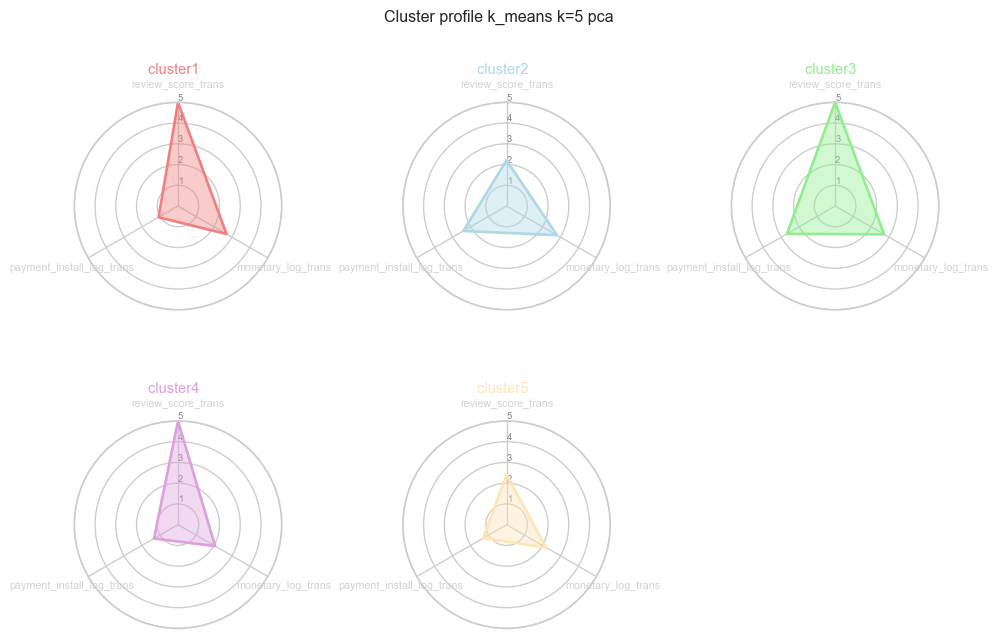

In [134]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi = 96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)

# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral', 'lightblue', 'lightgreen', 'plum', 'moccasin']
labels = ['', '', '', '', '']

# Loop to plot
for row in range(0, len(D.index)):
    make_spider(data=D, row=row+1, title='cluster'+str(row+1) +
                '  ' + str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=5 pca')
plt.tight_layout()

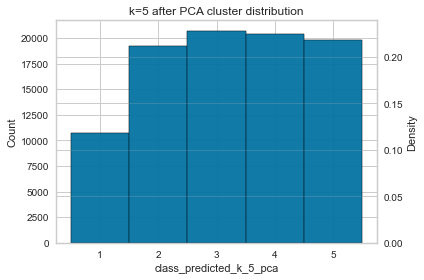

In [135]:
fig, ax = plt.subplots()

sns.histplot(full_df['class_predicted_k_5_pca'], discrete=True, ax=ax)

ax2 = ax.twinx()
sns.histplot(full_df['class_predicted_k_5_pca'],
             stat='density', discrete=True, ax=ax2)

plt.title('k=5 after PCA cluster distribution')
plt.xlabel('Cluster')
plt.xticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'])


plt.tight_layout()
plt.show()

In [304]:
full_df['silhouette_k_5_pca'] = silhouette_samples(
    full_df[['review_score_trans', 'monetary_log_trans', 'payment_install_log_trans']], full_df['class_predicted_k_5_pca'])

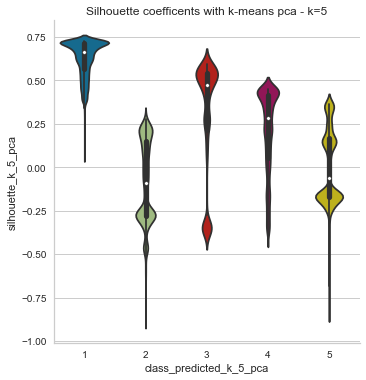

In [329]:
sns.catplot(x='class_predicted_k_5_pca',
            y='silhouette_k_5_pca', data=full_df, kind='violin')
plt.title('Silhouette coefficents with k-means pca - k=5')
plt.show()

### Adding reviews score variables

In [138]:
scaler = QuantileTransformer()

In [139]:
X_scaled = scaler.fit_transform(
    full_df[['recency_score', 'monetary_score', 'review_score']])

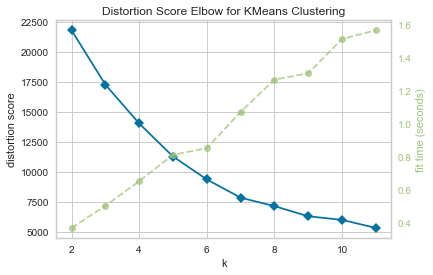

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [140]:
k_model = KMeans()
# Instantiate the clustering model and visualizer

visualizer = KElbowVisualizer(k_model, k=(2, 12), locate_elbow=False)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [141]:
model = KMeans(n_clusters=5)

In [142]:
model.fit(X_scaled)

KMeans(n_clusters=5)

In [143]:
full_df['class_predicted_k_5_review'] = model.predict(X_scaled)+1

In [315]:
full_df['silhouette_k_5_reviews'] = silhouette_samples(full_df[['recency_score', 'monetary_score', 'review_score']],
                                                       full_df['class_predicted_k_5_review'])

In [144]:
silh_scores['kmeans k=5 reviews'] = silhouette_score(full_df[['recency_score', 'monetary_score', 'review_score']],
                                                     full_df['class_predicted_k_5_review'])

In [145]:
silh_scores

{'Manual RFM': 0.20795312429036944,
 'kmeans k=3 SS': 0.26825863449089205,
 'kmeans k=3 QT': 0.38812702706029406,
 'kmeans k=5': 0.3808938773095665,
 'kmeans k=5 pca': 0.4226852332536575,
 'kmeans k=5 reviews': 0.2209638784134581}

In [146]:
scores_final = pd.DataFrame(index=silh_scores.keys())

In [147]:
scores_final['silhouette coefficient'] = silh_scores.values()

In [148]:
scores_final

,silhouette coefficient
Manual RFM,0.207953
kmeans k=3 SS,0.268259
kmeans k=3 QT,0.388127
kmeans k=5,0.380894
kmeans k=5 pca,0.422685
kmeans k=5 reviews,0.220964


In [10]:
np.save('data/quarters_df2', quarters_df, allow_pickle=True)

In [11]:
full_df.to_pickle('data/full_df2')

In [3]:
full_df = pd.read_pickle('data/full_df2')
quarters_df = np.load('data/quarters_df2.npy', allow_pickle=True)

### Using all variables

In [150]:
X_scaled = scaler.fit_transform(
    full_df[['recency_score',
             'monetary_score',
             'review_score',
             'frequency_score',
             'review_counts',
             'delivery_difference_time_log',
             'payment_installments'
            ]])

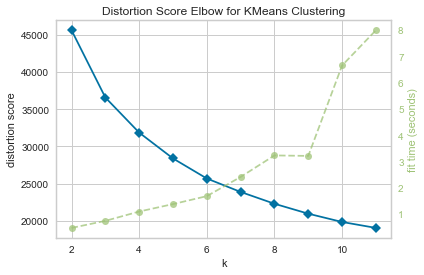

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [152]:
k_model = KMeans()
# Instantiate the clustering model and visualizer

visualizer = KElbowVisualizer(k_model, k=(2, 12), locate_elbow=False)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [158]:
model = KMeans(n_clusters=6)

In [159]:
model.fit(X_scaled)

KMeans(n_clusters=6)

In [160]:
full_df['class_predicted_k_6_all'] = model.predict(X_scaled)+1

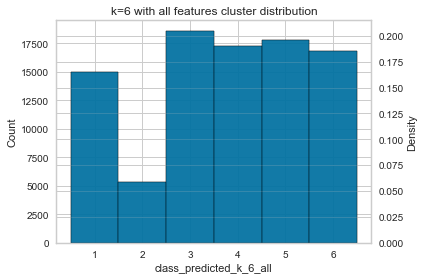

In [161]:
fig, ax = plt.subplots()

sns.histplot(full_df['class_predicted_k_6_all'], discrete=True, ax=ax)

ax2 = ax.twinx()
sns.histplot(full_df['class_predicted_k_6_all'],
             stat='density', discrete=True, ax=ax2)

plt.title('k=6 with all features cluster distribution')
plt.xlabel('Cluster')
plt.xticks([1, 2, 3,4,5,6], ['1', '2', '3','4','5','6'])


plt.tight_layout()
plt.show()

In [162]:
silh_scores['kmeans k=6 all'] = silhouette_score(full_df[['recency_score',
                                                          'monetary_score',
                                                          'review_score',
                                                          'frequency_score',
                                                          'review_counts',
                                                          'delivery_difference_time_log',
                                                          'payment_installments'
                                                          ]],
                                                 full_df['class_predicted_k_6_all'])

In [164]:
silh_scores

{'Manual RFM': 0.20795312429036944,
 'kmeans k=3 SS': 0.26825863449089205,
 'kmeans k=3 QT': 0.38812702706029406,
 'kmeans k=5': 0.3808938773095665,
 'kmeans k=5 pca': 0.4226852332536575,
 'kmeans k=5 reviews': 0.2209638784134581,
 'kmeans k=6 all': 0.05776350336678658}

In [163]:
full_df = create_visualisation_score(full_df, full_df[['recency_score',
                                                          'monetary_score',
                                                          'review_score',
                                                          'frequency_score',
                                                          'review_counts',
                                                          'delivery_difference_time_log',
                                                          'payment_installments'
                                                          ]], MinMaxScaler(feature_range=(0, 5)))

In [165]:
E = full_df.groupby('class_predicted_k_5_pca').mean()[['recency_score_trans',
                                                          'monetary_score_trans',
                                                          'review_score_trans',
                                                          'frequency_score_trans',
                                                          'review_counts_trans',
                                                          'delivery_difference_time_log_trans',
                                                          'payment_installments_trans'
                                                          ]]

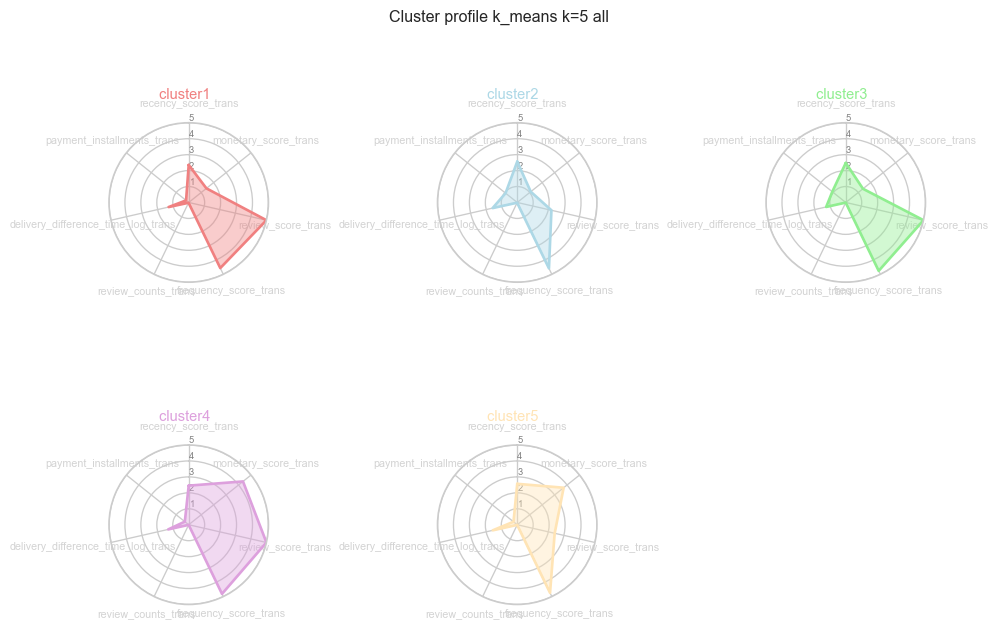

In [167]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi = 96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)

# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral', 'lightblue', 'lightgreen', 'plum', 'moccasin']
labels = ['', '', '', '', '']

# Loop to plot
for row in range(0, len(E.index)):
    make_spider(data=E, row=row+1, title='cluster'+str(row+1) +
                '  ' + str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=5 all')
plt.tight_layout()

## Clustering stability over time

In [13]:
quarters_df[5].columns

Index(['customer_unique_id', 'frequency', 'recency', 'monetary',
       'monetary_log', 'review_counts', 'review_score',
       'delivery_difference_time', 'delivery_difference_time_log',
       'payment_installments', 'frequency_QT', 'recency_QT', 'monetary_log_QT',
       'monetary_QT', 'review_counts_QT', 'review_score_QT',
       'delivery_difference_time_QT', 'delivery_difference_time_log_QT',
       'payment_installments_QT', 'frequency_score', 'recency_score',
       'monetary_score', 'RFM_score'],
      dtype='object')

In [4]:
def get_centroids(data, init='k-means++'):
    model = KMeans(n_clusters=5, random_state=4)
    X_scaled = data[['recency_QT', 'monetary_QT', 'frequency_QT']]
    model.fit(X_scaled)
    data['cluster'] = model.predict(X_scaled)
    D = data.groupby('cluster').mean()[['recency_score',
                                        'monetary_score',
                                        'frequency_score']]
    return D

In [5]:
centroids = []

In [6]:
for i in range(len(quarters_df)):
    centroids.append(get_centroids(quarters_df[i]))

### ARI and AMI

In [11]:
ARI = np.empty(shape=(6, 6))
AMI = np.empty(shape=(6, 6))

In [12]:
for j in range(len(quarters_df)):
    for i in range(j, len(quarters_df)):
        ARI[j][i] = adjusted_rand_score(
            quarters_df[j]['cluster'], quarters_df[i].loc[quarters_df[j].index]['cluster'])
        AMI[j][i] = adjusted_mutual_info_score(
            quarters_df[j]['cluster'], quarters_df[i].loc[quarters_df[j].index]['cluster'])

In [18]:
ARI = np.where(ARI == 0, np.nan, ARI)

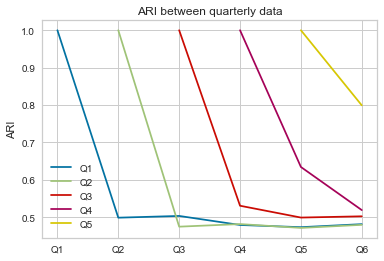

In [19]:
for i in range(len(quarters_df)-1):
    plt.plot(ARI[i],)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=[
           'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6'])
plt.ylabel('ARI')
plt.title('ARI between quarterly data')
plt.legend(['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6'])

### Centroids mobility over time

In [97]:
centroids_coord = np.empty((0, 4))

In [99]:
for i in range(len(centroids)):
    for j in range(len(centroids[i])):
        centroids_coord = np.vstack((centroids_coord, list(
            np.concatenate((list(centroids[i].values[j]), [i])))))

In [110]:
centroids_coord = pd.DataFrame(centroids_coord, columns=[
                               'recency', 'monetary', 'frequency', 'quarter'])

In [112]:
fig = px.scatter_3d(centroids_coord, x='recency',
                    y='monetary',
                    z='frequency',
                    color='quarter',
                    opacity=0.5)
fig.show()

### Customer migration from cluster to cluster

In [20]:
def compute_cluster_ID(data):
    name = ''
    if data['frequency_score'] < 1.5:
        name = 'F'
    else:
        if data['recency_score'] > 2.5:
            name += 'O'
        else:
            name += 'R'
        if data['monetary_score'] > 2.5:
            name += 'F'
        else:
            name += 'S'
    return name

In [21]:
def compute_cluster_name(data, centroids):
    cluster_map = centroids.apply(compute_cluster_ID, axis=1)
    data['cluster_name'] = [cluster_map[f] for f in data['cluster']]
    return data

In [22]:
for i in range(len(quarters_df)):
    quarters_df[i] = compute_cluster_name(quarters_df[i], centroids[i])

In [23]:
clusters_names = ['OS', 'RS', 'OF', 'RF', 'F']

In [24]:
I = {}

In [25]:
eff_change = {}

In [26]:
for i in range(len(quarters_df)-1):
    eff_change[i] = pd.DataFrame(columns=clusters_names, index=clusters_names)
    for name in clusters_names:
        I[name] = quarters_df[i][quarters_df[i]['cluster_name'] == name].index

    for j in range(len(clusters_names)):
        A = quarters_df[i+1].loc[I[clusters_names[j]]
                                 ].groupby('cluster_name').count()['customer_unique_id']
        eff_change[i] = eff_change[i].join(A)
        eff_change[i][clusters_names[j]] = eff_change[i]['customer_unique_id']
        eff_change[i] = eff_change[i].drop(columns=['customer_unique_id'])
    eff_change[i] = eff_change[i].fillna(0)

In [31]:
labels = []
for i in range(len(quarters_df)):
    for name in eff_change[0].columns:
        labels.append(name+f'_Q{i}')

In [39]:
colors = ['lightblue', 'lightcoral', 'lightgreen', 'mediumpurple', 'moccasin']

In [52]:
source = []
source_colors = []
for i in range(25):
    source += list(np.repeat(i, 5))
    source_colors += list(colors)

In [35]:
target = []
for i in range(5, 30, 5):
    target += 5 * [i, i+1, i+2, i+3, i+4]

In [37]:
value = []
for i in range(len(quarters_df)-1):
    value += list(eff_change[i].values.flatten(order='F'))

In [56]:
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=source_colors
    ),
    link=dict(
        source=source,  # indices correspond to labels, eg A1, A2, A1, B1, ...

        target=target,

        value=value,

        color=source_colors
    ))])

fig.update_layout(title_text="Quarterly Sankey Diagram", font_size=10)
fig.show()